# Phase 2 — ML Model Comparison

This notebook trains and compares **Logistic Regression**, **Random Forest**, and **XGBoost** for the `Is Laundering` target.

The dataset is highly imbalanced, so the notebook keeps every laundering transaction and samples legitimate transactions for a practical laptop experiment. It reports precision, recall, F1-score, ROC-AUC, PR-AUC, and confusion matrices. PR-AUC is especially important for this rare-event problem.

This is an experiment model, not yet the real-time production model. Kafka, FastAPI, SHAP, graph features, and agent integration come later.

## 1. Imports and configuration

Change `MAX_LEGITIMATE_ROWS` to make the experiment smaller or larger. The RTX 3060 can help XGBoost when CUDA is available. The notebook automatically falls back to CPU if GPU training is unavailable.

In [2]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "data/raw/HI-Small_Trans.csv").exists():
    ROOT = Path(r"C:\Users\akash\agentic-banking-fraud-platform")

RAW_TRANSACTION_PATH = ROOT / "data/raw/HI-Small_Trans.csv"
INSPECTION_PATH = ROOT / "phase1_data_foundation/outputs/reports/dataset_inspection.json"
OUTPUT_DIR = ROOT / "phase2_ml_models/outputs"
MODEL_DIR = ROOT / "phase2_ml_models/models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CHUNK_SIZE = 250_000
MAX_LEGITIMATE_ROWS = 500_000
TEST_SIZE = 0.20
print(f"Project root: {ROOT}")
print(f"Transaction file exists: {RAW_TRANSACTION_PATH.exists()}")


Project root: c:\Users\akash\agentic-banking-fraud-platform
Transaction file exists: True


## 2. Load a controlled, reproducible modeling sample

The transaction file contains more than 5 million rows but only a few thousand positive labels. The loader reads chunks, keeps all positive rows, and samples legitimate rows with a fixed seed. This avoids loading unnecessary rows into memory while preserving the rare class.

In [3]:
PHASE1_SRC = ROOT / "phase1_data_foundation/src"
sys.path.insert(0, str(PHASE1_SRC))
from preprocess import read_transaction_chunks

inspection = json.loads(INSPECTION_PATH.read_text(encoding="utf-8"))
total_legitimate = inspection["transactions"]["is_laundering_counts"]["0"]
sampling_fraction = min(1.0, MAX_LEGITIMATE_ROWS / total_legitimate)

positive_parts = []
legitimate_parts = []
legitimate_sampled = 0
started = time.time()

for chunk_number, chunk in enumerate(read_transaction_chunks(str(RAW_TRANSACTION_PATH), chunksize=CHUNK_SIZE), start=1):
    positives = chunk[chunk["Is Laundering"] == 1]
    legitimate = chunk[chunk["Is Laundering"] == 0]
    if not positives.empty:
        positive_parts.append(positives)
    if sampling_fraction < 1.0:
        sampled = legitimate.sample(frac=sampling_fraction, random_state=RANDOM_STATE + chunk_number)
    else:
        sampled = legitimate
    legitimate_parts.append(sampled)
    legitimate_sampled += len(sampled)
    if chunk_number % 5 == 0:
        print(f"Processed chunk {chunk_number}; sampled legitimate rows: {legitimate_sampled:,}")

positive_df = pd.concat(positive_parts, ignore_index=True)
legitimate_df = pd.concat(legitimate_parts, ignore_index=True)
if len(legitimate_df) > MAX_LEGITIMATE_ROWS:
    legitimate_df = legitimate_df.sample(n=MAX_LEGITIMATE_ROWS, random_state=RANDOM_STATE)

data = pd.concat([positive_df, legitimate_df], ignore_index=True)
data = data.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Sample loaded in {time.time() - started:.1f} seconds")
print(f"Positive rows: {len(positive_df):,}")
print(f"Legitimate rows: {len(legitimate_df):,}")
print(f"Total modeling rows: {len(data):,}")
print(data["Is Laundering"].value_counts().rename(index={0: "legitimate", 1: "laundering"}))


Processed chunk 5; sampled legitimate rows: 123,124
Processed chunk 10; sampled legitimate rows: 246,167
Processed chunk 15; sampled legitimate rows: 369,235
Processed chunk 20; sampled legitimate rows: 492,302
Sample loaded in 23.8 seconds
Positive rows: 5,177
Legitimate rows: 500,000
Total modeling rows: 505,177
Is Laundering
legitimate    500000
laundering      5177
Name: count, dtype: int64


## 3. Feature engineering

Raw account IDs are not used as direct features because they are identifiers and could encourage memorization. The initial comparison uses amounts, timing, bank relationship, currencies, and payment format. Historical behavior and graph-derived features will be added in later phases.

In [4]:
def build_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    frame = frame.copy()
    received = frame["Amount Received"].astype(float).clip(lower=0)
    paid = frame["Amount Paid"].astype(float).clip(lower=0)
    features = pd.DataFrame(index=frame.index)
    features["log_amount_received"] = np.log1p(received)
    features["log_amount_paid"] = np.log1p(paid)
    features["amount_difference"] = frame["Amount Difference"].astype(float)
    features["hour"] = frame["Hour"].astype(float)
    features["hour_sin"] = np.sin(2 * np.pi * features["hour"] / 24)
    features["hour_cos"] = np.cos(2 * np.pi * features["hour"] / 24)
    features["same_bank"] = (frame["From Bank"] == frame["To Bank"]).astype(int)
    features["same_currency"] = (frame["Receiving Currency"] == frame["Payment Currency"]).astype(int)
    features["payment_format"] = frame["Payment Format"].astype("string")
    features["receiving_currency"] = frame["Receiving Currency"].astype("string")
    features["payment_currency"] = frame["Payment Currency"].astype("string")
    return features, frame["Is Laundering"].astype(int)

X, y = build_features(data)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
numeric_features = ["log_amount_received", "log_amount_paid", "amount_difference", "hour", "hour_sin", "hour_cos", "same_bank", "same_currency"]
categorical_features = ["payment_format", "receiving_currency", "payment_currency"]
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
print(f"Train shape: {X_train.shape}; validation shape: {X_valid.shape}")
print(f"Train laundering rate: {y_train.mean():.4%}")
print(f"Validation laundering rate: {y_valid.mean():.4%}")


Train shape: (404141, 11); validation shape: (101036, 11)
Train laundering rate: 1.0249%
Validation laundering rate: 1.0244%


## 4. Define Logistic Regression, Random Forest, and XGBoost

Logistic Regression is the linear baseline. Random Forest captures nonlinear interactions on CPU. XGBoost is the main tabular candidate and is attempted on CUDA first. Class weighting compensates for the imbalanced sampled training set.

In [5]:
positive_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
models = {
    "logistic_regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=300, class_weight="balanced", solver="saga", n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, max_depth=18, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
}
xgb_common = dict(
    n_estimators=300, max_depth=8, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85, min_child_weight=2,
    reg_lambda=1.0, scale_pos_weight=positive_weight,
    eval_metric="aucpr", tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
print(f"scale_pos_weight: {positive_weight:.2f}")


scale_pos_weight: 96.57


## 5. Train Logistic Regression and Random Forest

Random Forest may take several minutes depending on CPU speed and available memory. Wait for this cell to finish before starting XGBoost.

In [6]:
trained_models = {}
training_times = {}
for name, model in models.items():
    print(f"Training {name}...")
    started = time.time()
    model.fit(X_train, y_train)
    training_times[name] = time.time() - started
    trained_models[name] = model
    print(f"Finished {name} in {training_times[name] / 60:.2f} minutes")


Training logistic_regression...


c:\Users\akash\agentic-banking-fraud-platform\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\akash\agentic-banking-fraud-platform\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Finished logistic_regression in 1.30 minutes
Training random_forest...
Finished random_forest in 1.09 minutes


## 6. Train XGBoost with GPU fallback

If CUDA is supported, XGBoost uses `device="cuda"`. If it fails, the notebook retries with `device="cpu"` so the experiment still completes.

In [7]:
print("Training XGBoost with GPU attempt...")
started = time.time()
try:
    xgb_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**xgb_common, device="cuda")),
    ])
    xgb_model.fit(X_train, y_train)
    xgb_mode = "GPU (CUDA)"
except Exception as gpu_error:
    print(f"GPU unavailable: {type(gpu_error).__name__}: {gpu_error}")
    print("Retrying XGBoost on CPU...")
    xgb_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**xgb_common, device="cpu")),
    ])
    xgb_model.fit(X_train, y_train)
    xgb_mode = "CPU fallback"
training_times["xgboost"] = time.time() - started
trained_models["xgboost"] = xgb_model
print(f"XGBoost mode: {xgb_mode}; time: {training_times['xgboost'] / 60:.2f} minutes")


Training XGBoost with GPU attempt...
XGBoost mode: GPU (CUDA); time: 0.05 minutes


## 7. Evaluate using fraud-focused metrics

We report precision, recall, F1-score, ROC-AUC, and PR-AUC. Accuracy is intentionally not used as the main selection metric because a model can achieve high accuracy by predicting almost every transaction as legitimate.

In [8]:
metrics = {}
probabilities = {}
predictions = {}
for name, model in trained_models.items():
    probability = model.predict_proba(X_valid)[:, 1]
    prediction = (probability >= 0.50).astype(int)
    probabilities[name] = probability
    predictions[name] = prediction
    metrics[name] = {
        "precision": float(precision_score(y_valid, prediction, zero_division=0)),
        "recall": float(recall_score(y_valid, prediction, zero_division=0)),
        "f1": float(f1_score(y_valid, prediction, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_valid, probability)),
        "pr_auc": float(average_precision_score(y_valid, probability)),
        "training_seconds": float(training_times[name]),
    }
    print(f"\n{name}")
    print(json.dumps(metrics[name], indent=2))
    print(classification_report(y_valid, prediction, target_names=["legitimate", "laundering"], zero_division=0))
metrics_df = pd.DataFrame(metrics).T.sort_values("pr_auc", ascending=False)
metrics_df



logistic_regression
{
  "precision": 0.07885684043397724,
  "recall": 0.863768115942029,
  "f1": 0.14451988360814744,
  "roc_auc": 0.9146995824727743,
  "pr_auc": 0.1465252066638417,
  "training_seconds": 78.0005464553833
}
              precision    recall  f1-score   support

  legitimate       1.00      0.90      0.94    100001
  laundering       0.08      0.86      0.14      1035

    accuracy                           0.90    101036
   macro avg       0.54      0.88      0.54    101036
weighted avg       0.99      0.90      0.94    101036


random_forest
{
  "precision": 0.14290669441553938,
  "recall": 0.7961352657004831,
  "f1": 0.24231730627848846,
  "roc_auc": 0.9244086061554844,
  "pr_auc": 0.3006122228341508,
  "training_seconds": 65.3529908657074
}
              precision    recall  f1-score   support

  legitimate       1.00      0.95      0.97    100001
  laundering       0.14      0.80      0.24      1035

    accuracy                           0.95    101036
   macro a

c:\Users\akash\agentic-banking-fraud-platform\.venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [21:53:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,precision,recall,f1,roc_auc,pr_auc,training_seconds
xgboost,0.127148,0.807729,0.219711,0.921651,0.345607,2.704599
random_forest,0.142907,0.796135,0.242317,0.924409,0.300612,65.352991
logistic_regression,0.078857,0.863768,0.144520,0.914700,0.146525,78.000546


## 8. Confusion matrices and ROC/precision-recall curves

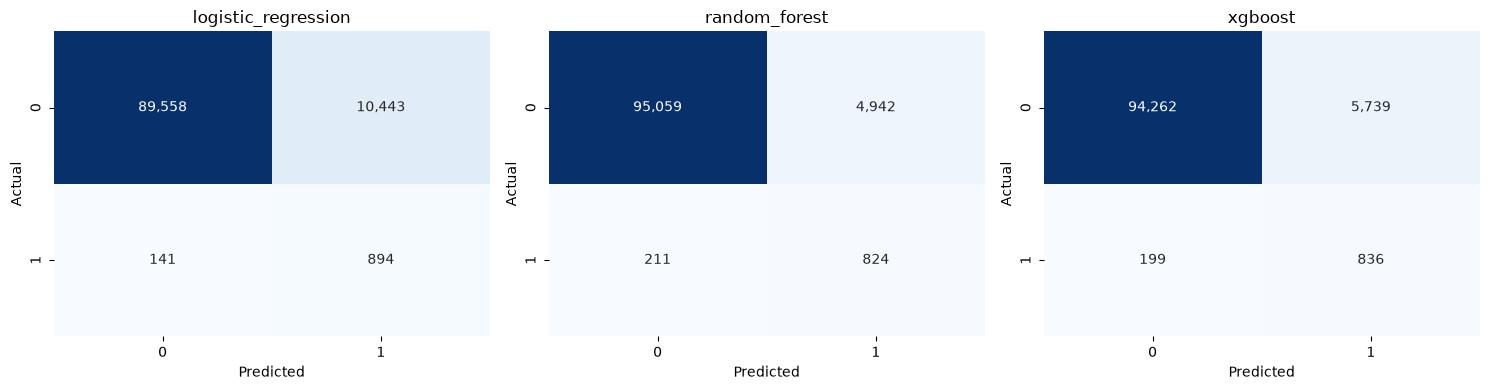

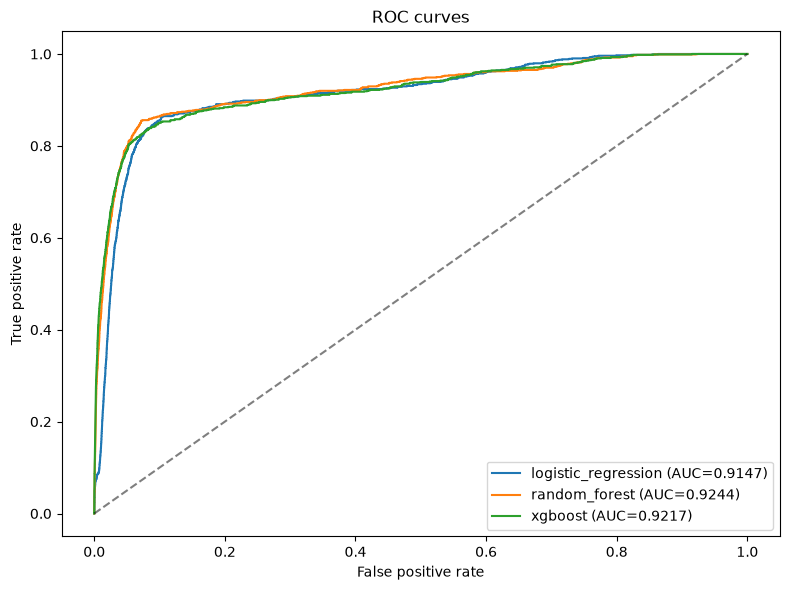

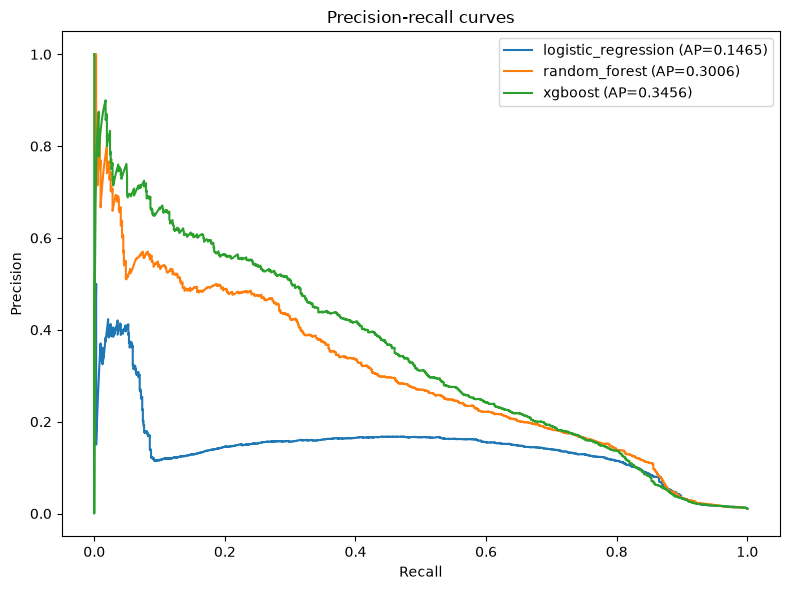

In [9]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(15, 4))
for ax, (name, prediction) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_valid, prediction), annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_valid, probability)
    plt.plot(fpr, tpr, label=f"{name} (AUC={metrics[name]['roc_auc']:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 6))
for name, probability in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_valid, probability)
    plt.plot(recall, precision, label=f"{name} (AP={metrics[name]['pr_auc']:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall_curves.png", dpi=150)
plt.show()


## 9. Tune the alert threshold

A probability threshold of 0.50 is only a starting point. In AML, the threshold controls the trade-off between missed laundering transactions and investigator workload. We choose a threshold for the best PR-AUC model while requiring at least 80% recall on this validation split.

Model selected by PR-AUC: xgboost
Operational threshold: 0.55


,model,threshold,precision,recall,f1
38,xgboost,0.05,0.024293,0.914976,0.047329
39,xgboost,0.10,0.041570,0.885024,0.079410
40,xgboost,0.15,0.058018,0.867633,0.108763
41,xgboost,0.20,0.072235,0.853140,0.133193
42,xgboost,0.25,0.085009,0.845411,0.154484
43,xgboost,0.30,0.095327,0.835749,0.171135
44,xgboost,0.35,0.103846,0.827053,0.184523
45,xgboost,0.40,0.111638,0.819324,0.196501
46,xgboost,0.45,0.120286,0.813527,0.209583
47,xgboost,0.50,0.127148,0.807729,0.219711


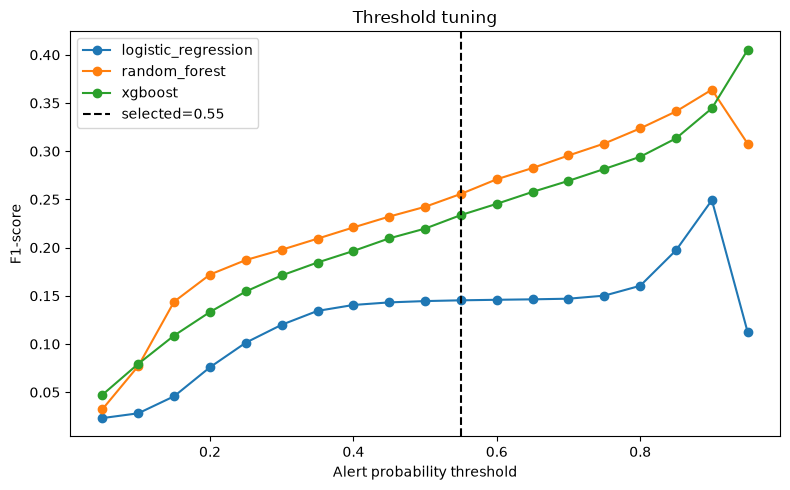

Saved model: c:\Users\akash\agentic-banking-fraud-platform\phase2_ml_models\models\best_model_xgboost.joblib


In [10]:
threshold_rows = []
thresholds = np.arange(0.05, 0.96, 0.05)
for name, probability in probabilities.items():
    for threshold in thresholds:
        prediction = (probability >= threshold).astype(int)
        threshold_rows.append({
            "model": name,
            "threshold": float(threshold),
            "precision": float(precision_score(y_valid, prediction, zero_division=0)),
            "recall": float(recall_score(y_valid, prediction, zero_division=0)),
            "f1": float(f1_score(y_valid, prediction, zero_division=0)),
        })
threshold_df = pd.DataFrame(threshold_rows)
best_model_name = metrics_df.index[0]
eligible_thresholds = threshold_df[(threshold_df["model"] == best_model_name) & (threshold_df["recall"] >= 0.80)]
if eligible_thresholds.empty:
    selected_threshold_row = threshold_df[threshold_df["model"] == best_model_name].sort_values("f1", ascending=False).iloc[0]
else:
    selected_threshold_row = eligible_thresholds.sort_values(["f1", "precision"], ascending=False).iloc[0]
best_threshold = float(selected_threshold_row["threshold"])
print(f"Model selected by PR-AUC: {best_model_name}")
print(f"Operational threshold: {best_threshold:.2f}")
display(threshold_df[threshold_df["model"] == best_model_name].sort_values("threshold"))

plt.figure(figsize=(8, 5))
for name in threshold_df["model"].unique():
    subset = threshold_df[threshold_df["model"] == name]
    plt.plot(subset["threshold"], subset["f1"], marker="o", label=name)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"selected={best_threshold:.2f}")
plt.xlabel("Alert probability threshold")
plt.ylabel("F1-score")
plt.title("Threshold tuning")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_tuning.png", dpi=150)
plt.show()

# Select and save the best model. The pipeline includes preprocessing.
best_model = trained_models[best_model_name]
model_path = MODEL_DIR / f"best_model_{best_model_name}.joblib"
joblib.dump(best_model, model_path)
(OUTPUT_DIR / "model_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
(OUTPUT_DIR / "threshold_metrics.json").write_text(threshold_df.to_json(orient="records", indent=2), encoding="utf-8")
(OUTPUT_DIR / "training_config.json").write_text(json.dumps({
    "best_model": best_model_name,
    "operational_threshold": best_threshold,
    "minimum_recall_constraint": 0.80,
    "xgboost_mode": xgb_mode,
    "max_legitimate_rows": MAX_LEGITIMATE_ROWS,
    "positive_rows": int(len(positive_df)),
    "legitimate_rows": int(len(legitimate_df)),
    "random_state": RANDOM_STATE,
    "features": numeric_features + categorical_features,
}, indent=2), encoding="utf-8")
print(f"Saved model: {model_path}")


## 10. Questions for the project report

- Which model achieved the highest PR-AUC?
- Which model had the best recall?
- How many false positives and false negatives did the selected model produce?
- Was XGBoost trained with GPU or CPU fallback?
- Why is PR-AUC more informative than accuracy for this dataset?

The selected model will later be connected to Kafka and FastAPI. SHAP explanations, historical behavior, and graph-derived features will be added in later phases.